<a href="https://colab.research.google.com/github/josenomberto/UTEC-CDIAV3-MCD8010/blob/main/proyecto1_v3.0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch numpy pandas scikit-learn networkx matplotlib

# 1. Importación de Librerias


In [15]:
import numpy as np
import pandas as pd
import torch
import torch.optim as optim

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import networkx as nx
import matplotlib.pyplot as plt


# 2. Cargar y preparar el dataset

In [16]:
# Load dataset
df = pd.read_csv("OnlineNewsPopularity.csv")
df.columns = df.columns.str.strip()

# Remove non-predictive column
df = df.drop(columns=["url"])

# Target transformation
df["log_shares"] = np.log1p(df["shares"])

# Separate features and target
#X = df.drop(columns=["shares", "log_shares"])
X = df.drop(columns=["shares"])
y = df["log_shares"]

feature_names = X.columns.tolist()


# 3. Escalado (CRÍTICO para NOTEARS)

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert to torch tensor
X_tensor = torch.from_numpy(X_scaled).float()


#4. Implementacion de NOTEARS

## 4.1 Funciones base

In [18]:
def h_func(W):
    d = W.shape[0]
    return torch.trace(torch.matrix_exp(W * W)) - d


def notears_loss(X, W):
    n = X.shape[0]
    loss = 0.5 / n * torch.sum((X - X @ W) ** 2)
    return loss


## 4.2 Entrenamiento NOTEARS

In [19]:
def notears_linear(X, lambda1=0.01, max_iter=100, lr=0.01):
    d = X.shape[1]
    W = torch.zeros(d, d, requires_grad=True)

    optimizer = optim.Adam([W], lr=lr)

    for i in range(max_iter):
        optimizer.zero_grad()

        loss = notears_loss(X, W)
        h = h_func(W)
        l1 = lambda1 * torch.sum(torch.abs(W))

        obj = loss + l1 + 10 * h * h
        obj.backward()
        optimizer.step()

        if i % 10 == 0:
            print(f"Iter {i} | Loss: {loss.item():.4f} | h(W): {h.item():.6f}")

    return W.detach().numpy()


## 4.2 Ejeccución de NOTEARS

In [27]:
# Optional: use subset for speed
X_sub = X_tensor[:5000]

W_est = notears_linear(X_sub, lambda1=0.01, max_iter=100)


Iter 0 | Loss: 33.1413 | h(W): 0.000000
Iter 10 | Loss: 15.7190 | h(W): 0.400883
Iter 20 | Loss: 12.5038 | h(W): 0.319489
Iter 30 | Loss: 11.6223 | h(W): 0.345776
Iter 40 | Loss: 11.2867 | h(W): 0.343506
Iter 50 | Loss: 11.2678 | h(W): 0.317631
Iter 60 | Loss: 11.1605 | h(W): 0.310699
Iter 70 | Loss: 11.0444 | h(W): 0.309910
Iter 80 | Loss: 10.9661 | h(W): 0.306145
Iter 90 | Loss: 10.8857 | h(W): 0.303493


# 5. Construcción del DAG causal

## 5.1 Crear grafo dirigido

In [21]:
threshold = 0.05  # remove weak causal links

G = nx.DiGraph()

for i, src in enumerate(feature_names):
    for j, tgt in enumerate(feature_names):
        if abs(W_est[i, j]) > threshold:
            G.add_edge(src, tgt, weight=W_est[i, j])


## 5.2 Visualizacion del DAG

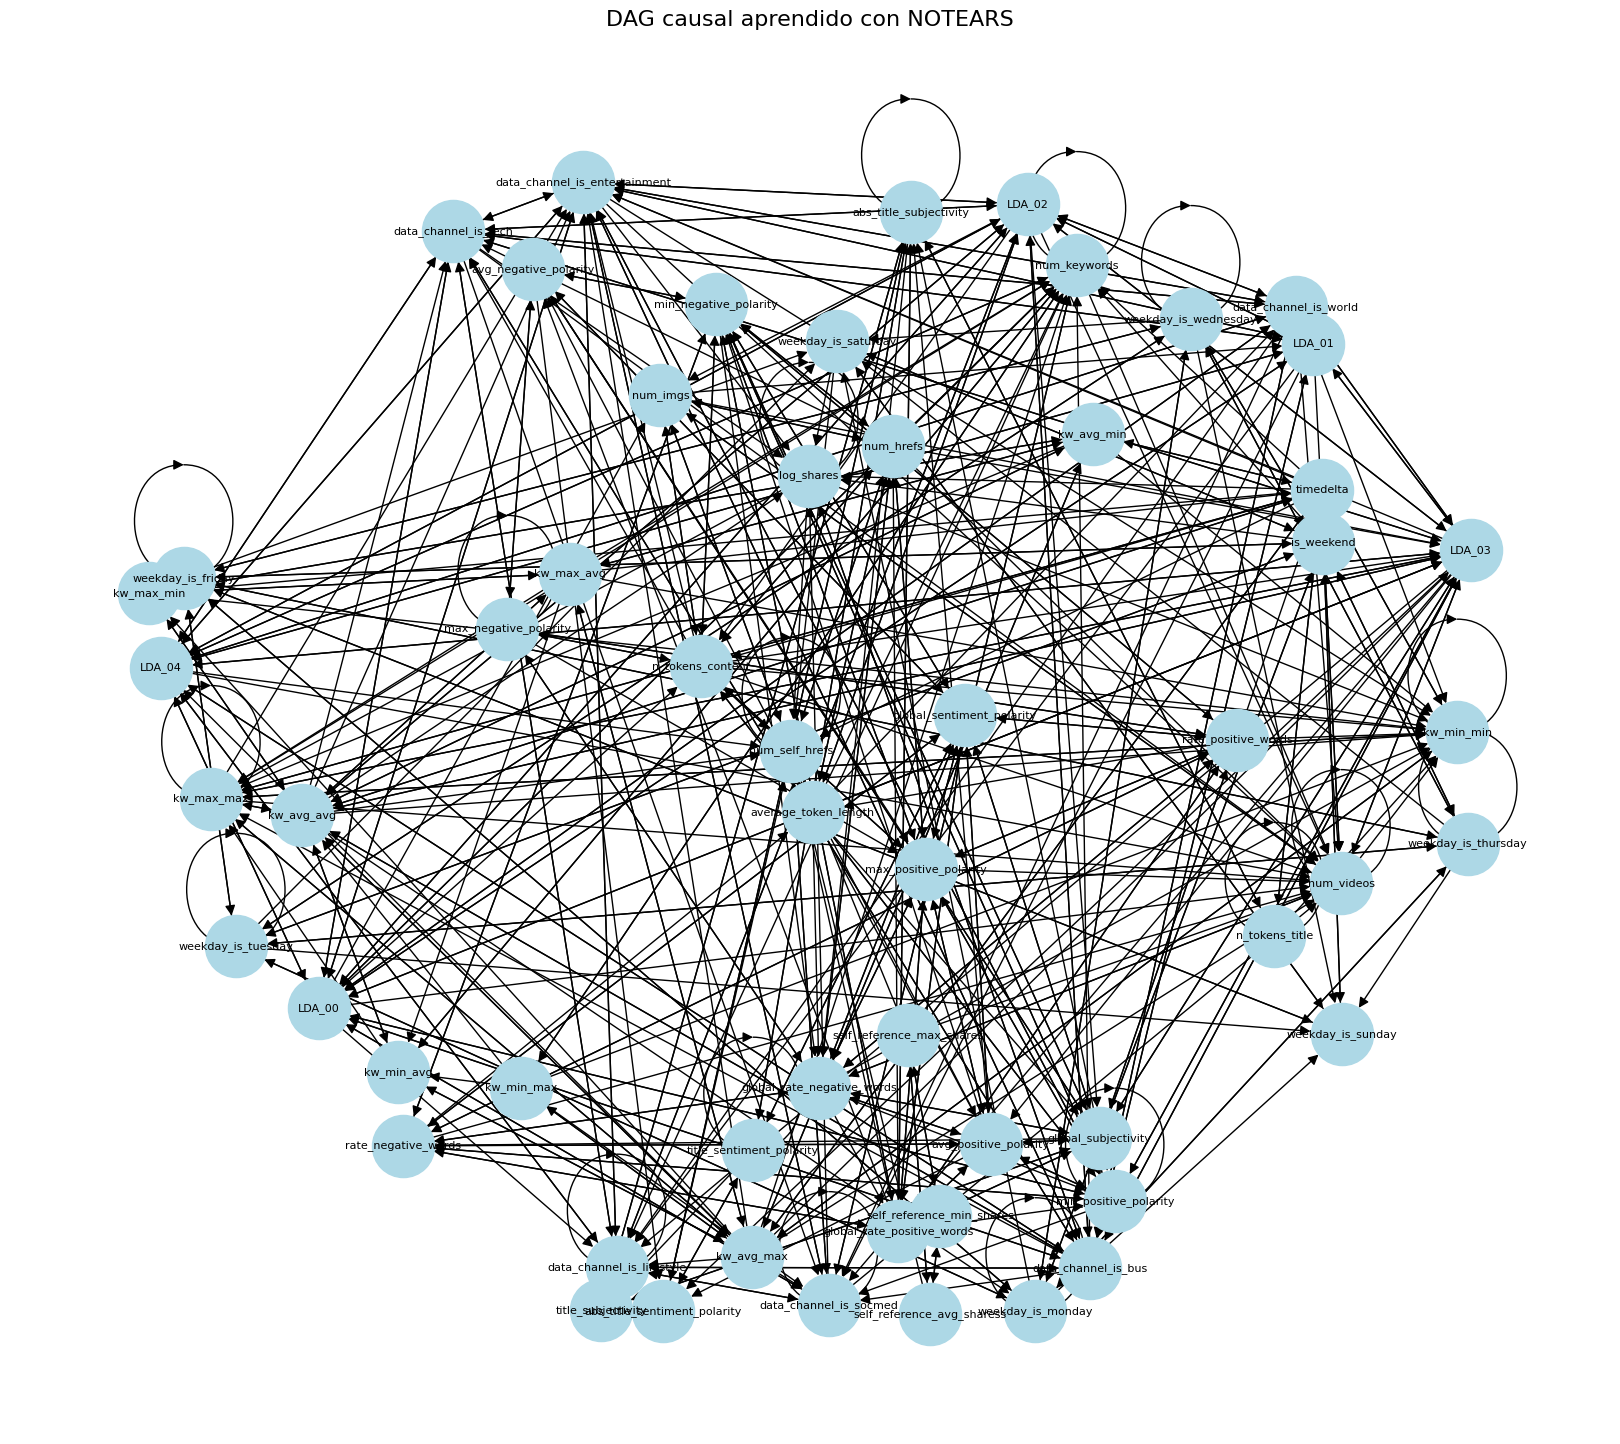

In [22]:
plt.figure(figsize=(16, 14))
pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2000,
    node_color="lightblue",
    font_size=8,
    arrowsize=15
)

plt.title("DAG causal aprendido con NOTEARS", fontsize=16)
plt.show()


# 6. Identificar features con mayor causalidad hacia shares

In [23]:
target = "log_shares"
target_idx = feature_names.index(target)

threshold = 0.05
parents = []

for i, src in enumerate(feature_names):
    if src == target:
        continue

    weight = W_est[i, target_idx]

    if abs(weight) > threshold:
        parents.append((src, weight))

parents_df = (
    pd.DataFrame(parents, columns=["Feature", "Causal_Weight"])
    .assign(abs_weight=lambda x: x["Causal_Weight"].abs())
    .sort_values("abs_weight", ascending=False)
    .drop(columns="abs_weight")
)

parents_df


,Feature,Causal_Weight
5,kw_avg_avg,0.106256
6,weekday_is_saturday,0.073788
7,is_weekend,0.071636
0,timedelta,0.062298
3,data_channel_is_socmed,0.058598
2,data_channel_is_bus,-0.056107
4,data_channel_is_tech,0.052791
1,data_channel_is_entertainment,-0.051152


# 7. Subgrafo causal hacia shares (BONITO PARA PAPER)

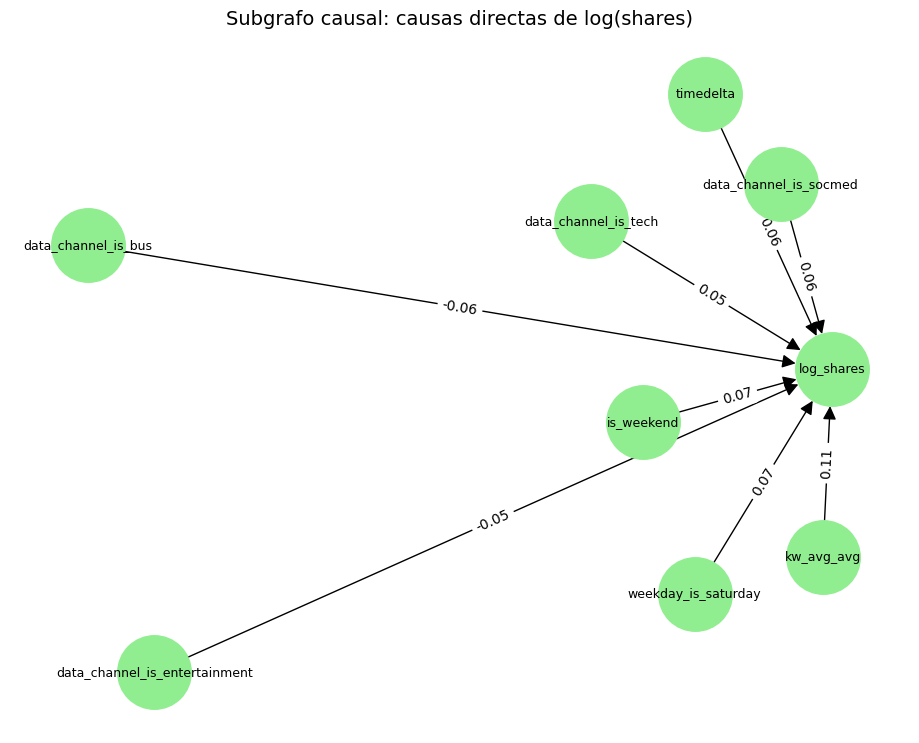

In [24]:
import networkx as nx
import matplotlib.pyplot as plt

G_shares = nx.DiGraph()

for feature, weight in parents:
    G_shares.add_edge(feature, "log_shares", weight=weight)

plt.figure(figsize=(9, 7))
pos = nx.spring_layout(G_shares, seed=42)

nx.draw(
    G_shares,
    pos,
    with_labels=True,
    node_size=2800,
    node_color="lightgreen",
    arrowsize=20,
    font_size=9
)

edge_labels = {
    (u, v): f"{d['weight']:.2f}"
    for u, v, d in G_shares.edges(data=True)
}

nx.draw_networkx_edge_labels(G_shares, pos, edge_labels=edge_labels)

plt.title("Subgrafo causal: causas directas de log(shares)", fontsize=14)
plt.show()



In [25]:
causal_features = parents_df["Feature"].tolist()
print(causal_features)

['kw_avg_avg', 'weekday_is_saturday', 'is_weekend', 'timedelta', 'data_channel_is_socmed', 'data_channel_is_bus', 'data_channel_is_tech', 'data_channel_is_entertainment']


#

In [28]:
# EXTRAER PESOS CAUSALES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Target
target = "log_shares"
target_idx = feature_names.index(target)

# Extraer pesos causales: feature_i → log_shares
causal_weights = []

for i, feature in enumerate(feature_names):
    if feature == target:
        continue  # excluir self-loop

    weight = W_est[i, target_idx]
    causal_weights.append((feature, weight))


In [29]:
# CREAR DATAFRAME ORDENADO POR CAUSALIDAD ABSOLUTA

causal_df = (
    pd.DataFrame(causal_weights, columns=["Feature", "Causal_Weight"])
    .assign(Abs_Weight=lambda x: x["Causal_Weight"].abs())
    .sort_values("Abs_Weight", ascending=False)
    .reset_index(drop=True)
)

causal_df.head(10)


,Feature,Causal_Weight,Abs_Weight
0,kw_avg_avg,0.106256,0.106256
1,weekday_is_saturday,0.073788,0.073788
2,is_weekend,0.071636,0.071636
3,timedelta,0.062298,0.062298
4,data_channel_is_socmed,0.058598,0.058598
5,data_channel_is_bus,-0.056107,0.056107
6,data_channel_is_tech,0.052791,0.052791
7,data_channel_is_entertainment,-0.051152,0.051152
8,kw_max_max,0.047732,0.047732
9,LDA_02,-0.045997,0.045997


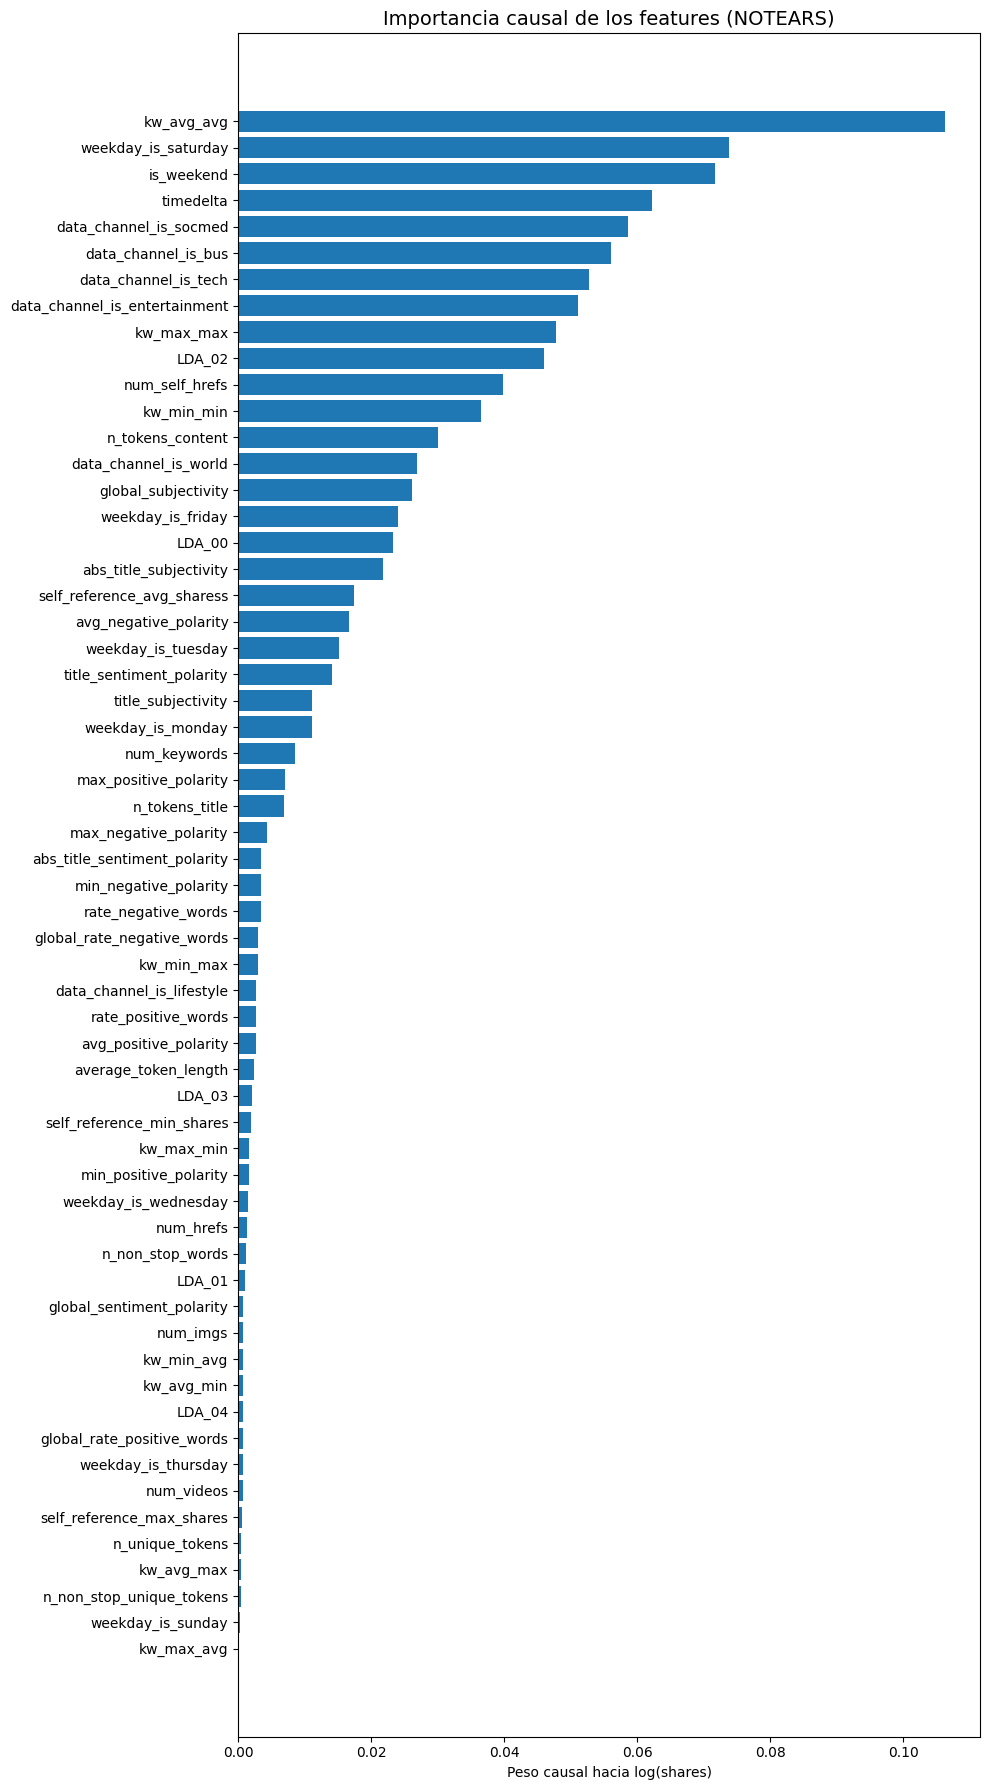

In [34]:
# DIAGRAMA DE BARRA DE TODOS LOS FEATURES

plt.figure(figsize=(10, 18))

plt.barh(
    causal_df["Feature"],
    #causal_df["Causal_Weight"]
    causal_df["Abs_Weight"]
)

plt.gca().invert_yaxis()  # mayor causalidad arriba
plt.xlabel("Peso causal hacia log(shares)")
plt.title("Importancia causal de los features (NOTEARS)", fontsize=14)

plt.tight_layout()
plt.show()


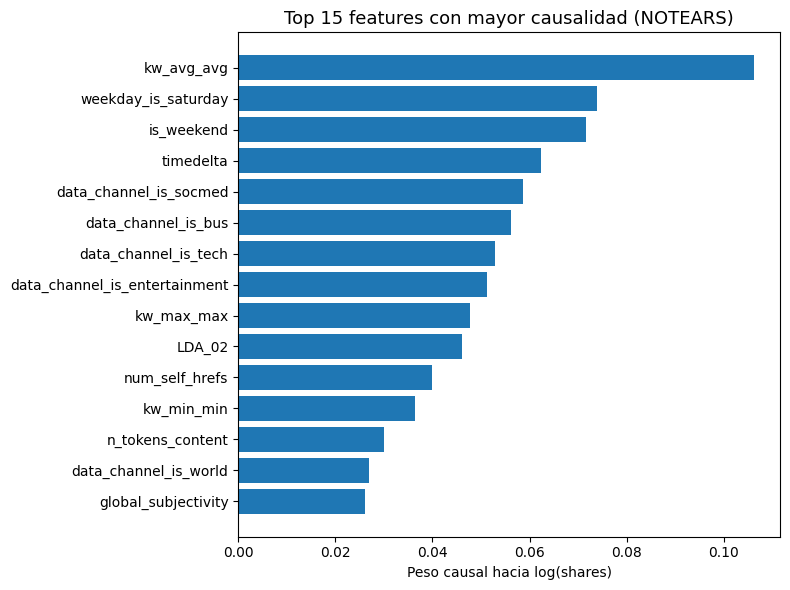

In [36]:
# DIAGRAMA TOP_K FEATURES CAUSALES

TOP_K = 15

top_causal_df = causal_df.head(TOP_K)

plt.figure(figsize=(8, 6))

plt.barh(
    top_causal_df["Feature"],
    #top_causal_df["Causal_Weight"]
    top_causal_df["Abs_Weight"]
)

plt.gca().invert_yaxis()
plt.xlabel("Peso causal hacia log(shares)")
plt.title(f"Top {TOP_K} features con mayor causalidad (NOTEARS)", fontsize=13)

plt.tight_layout()
plt.show()
